## Data Preparation and Cleaning ##
The raw datasets are loaded and prepared for spatial and temporal analysis. 
The workflow includes data loading, variable selection, data type conversion and the transformation of tabular data into geospatial formats and setting the CRS (CH1903+ / LV95)

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import functions 
import pandas as pd
from shapely.geometry import Point
from shapely import wkt
import geopandas as gpd
import mapclassify


raw_zwn = pd.read_csv("../data/raw/zwn_meldungen.csv")
raw_popsize = pd.read_csv("../data/raw/populationsize_zh.csv")
raw_quartiere = pd.read_csv("../data/raw/quartiere_zürich.csv")


#select needed columns
processed_zwn = raw_zwn[["service_name","requested_datetime","e","n","status","updated_datetime"]]
processed_quartiere = raw_quartiere[["qname","geometry"]]
pop_size = raw_popsize[["QuarLang","AnzBestWir","StichtagDatJahr"]]


#define new column names
new_names = {
"service_name":"category",
"e":"East",
"n":"North",
"requested_datetime":"report_time",
"updated_datetime":"resolved_time",
    }
processed_zwn= processed_zwn.rename(columns=new_names)

new_names1 = {
"qname":"Quartier",
    "geometry": "Geometry"
}
processed_quartiere= processed_quartiere.rename(columns=new_names1)

new_names_2 = {
"QuarLang":"Quartier",
"AnzBestWir":"PopSize",
}
pop_size= pop_size.rename(columns=new_names_2)

# Check missing values

#-------------------------------------------------------------------------------------------------------------------------
# Prepare processed_zwn dataset
#-------------------------------------------------------------------------------------------------------------------------

# convert datatype of "report_time" and "resolved_time" to datetime64
processed_zwn["report_time"] = pd.to_datetime(processed_zwn["report_time"], format ="%Y-%m-%dT%H:%M:%S")
processed_zwn["resolved_time"] = pd.to_datetime(processed_zwn["resolved_time"], format ="%Y-%m-%dT%H:%M:%S")

# create GeoDataFrame using the East and North coordinates as point geometry
processed_zwn = gpd.GeoDataFrame(processed_zwn,geometry=gpd.points_from_xy(processed_zwn["East"], processed_zwn["North"])
)
# select useful columns (without East and North)
#processed_zwn= processed_zwn[["category","report_time","geometry","status","resolved_time"]]

#define CRS (CH1903+ / LV95)
processed_zwn = processed_zwn.set_crs(epsg=2056)

#-------------------------------------------------------------------------------------------------------------------------
# Prepare processed_quartiere dataset
#-------------------------------------------------------------------------------------------------------------------------

# Convert geometry column from string format into geometry objects
processed_quartiere["Geometry"] = processed_quartiere["Geometry"].apply(wkt.loads)

#define "Geometry" column as spatial geometry in a GeoDataFrame
processed_quartiere = gpd.GeoDataFrame(
    processed_quartiere,
    geometry="Geometry")

#define missing CRS (CH1903+ / LV95)
processed_quartiere = processed_quartiere.set_crs(epsg=2056)


#-------------------------------------------------------------------------------------------------------------------------
# Prepare pop_size dataset
#-------------------------------------------------------------------------------------------------------------------------

# choose year 2025
pop_size= pop_size[raw_popsize["StichtagDatJahr"]	== 2025]

#-------------------------------------------------------------------------------------------------------------------------
#perform spatial join, gehöhrt nicht mehr zu Data Cleaning !!
#-------------------------------------------------------------------------------------------------------------------------
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="intersects")

## Question 1a: What categories of problems are most frequently reported in each neighbourhood?

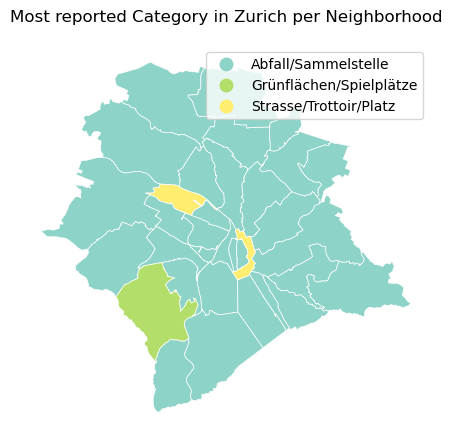

In [118]:

#---------------------------------------------------------------------------------------------------
#Data Analysis: choose category with the most reported problems per neighbourhood
#---------------------------------------------------------------------------------------------------
count = zwn_with_quartiere.groupby(["Quartier","category"]).size().reset_index(name="count")
result = count.sort_values(["Quartier", "count"], ascending=[True, False]).drop_duplicates("Quartier")
map_df = processed_quartiere.merge(result, on="Quartier",how="left")

#---------------------------------------------------------------------------------------------------------
# Create Map
#---------------------------------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10,5)) # creates empty figure 

map_df.plot(
    column="category", 
    categorical=True,
    edgecolor = "white",
    legend=True,
    linewidth = 0.5,
    cmap = "Set3",
    ax=ax,)
 

ax.axis("off")
ax.set_title("Most reported Category in Zurich per Neighborhood") 
plt.show()


## Question 1b: Is "Abfall/Sammelstelle concentrated in particular neighbourhoods?

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


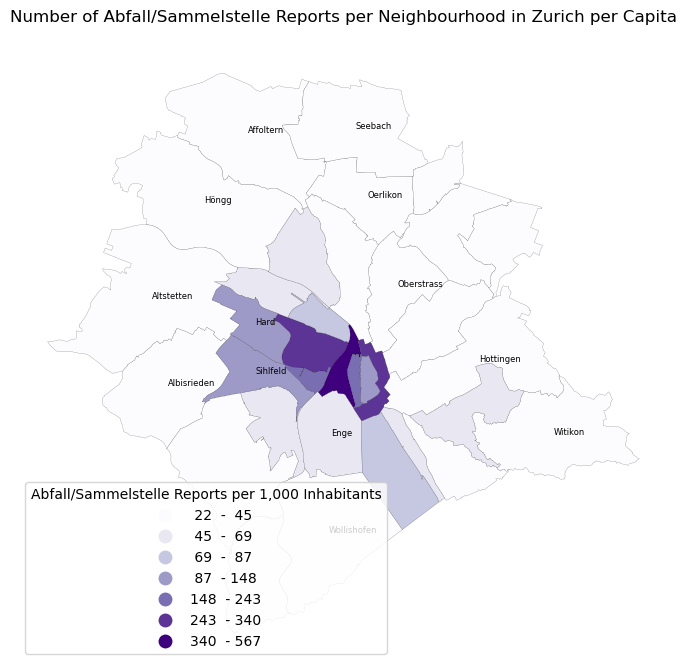

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


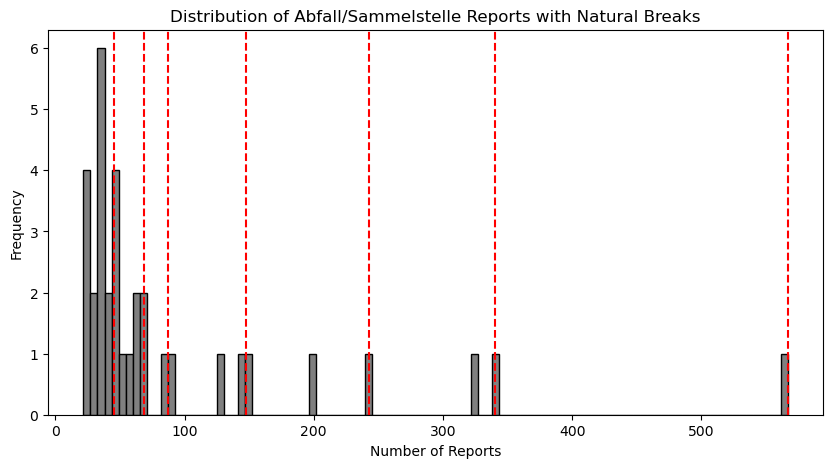

In [119]:
# ------------------------------------------------------------
# Prepare population and category data
# ------------------------------------------------------------
quartier_popsize=processed_quartiere.merge(pop_size, on="Quartier",how="left")

# Filter for selected issue category (changeable)
filtered_category = count[count["category"]=="Abfall/Sammelstelle"]

category_quartier_popsize=quartier_popsize.merge(filtered_category, on = "Quartier", how="left")

#---------------------------------------------------------------------------------------------------
#Data Analysis: Calculate number of reports per 1,000 inhabitants per neighbourhood
#---------------------------------------------------------------------------------------------------
category_quartier_popsize["Abfallreports_per_capita"] = (category_quartier_popsize["count"]/category_quartier_popsize["PopSize"]*1000)


#---------------------------------------------------------------------------------------------------------
# Create Chloropleth Map
#---------------------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16,8)) 


category_quartier_popsize.plot(
    column="Abfallreports_per_capita",
   scheme = "naturalbreaks",
   k = 7,
   edgecolor = "black",
    legend=True,
    linewidth = 0.1,
    cmap="Purples",
    ax=ax, #draw the axes on the axes we creaed
    legend_kwds={"title": "Abfall/Sammelstelle Reports per 1,000 Inhabitants","fmt": "{:.0f}"}
)
legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(text.get_text().replace(",", "  -"))
ax.set_title("Number of Abfall/Sammelstelle Reports per Neighbourhood in Zurich per Capita")
ax.axis("off")

# add neighbourhood labels
selected_quartiere =category_quartier_popsize[category_quartier_popsize["Quartier"].isin(["Affoltern","Seebach","Oerlikon","Höngg","Altstetten","Albisrieden","Enge","Wollishofen","Witikon","Hottingen","Sihlfeld","Hard","Oberstrass"])]

for i in range(len(selected_quartiere)):

    x = selected_quartiere.iloc[i]["Geometry"].centroid.x
    y = selected_quartiere.iloc[i]["Geometry"].centroid.y
    name = selected_quartiere.iloc[i]["Quartier"]

    ax.text(x, y, name, fontsize=6)

plt.show()

#--------------------------------------------------------------------------------------------------------
# Create histogram
#--------------------------------------------------------------------------------------------------------

# create natural break classifier and extract class breaks
classifier = mapclassify.NaturalBreaks(category_quartier_popsize["Abfallreports_per_capita"],k=7)
breaks = classifier.bins


plt.figure(figsize=(10,5))
plt.hist(category_quartier_popsize["Abfallreports_per_capita"], bins=100, color= "grey",edgecolor="black")

# Draw red lines at the Natural Break position
for i in breaks:
    plt.axvline(i, color="red", linestyle="--")

plt.title("Distribution of Abfall/Sammelstelle Reports with Natural Breaks")
plt.xlabel("Number of Reports")
plt.ylabel("Frequency")

plt.show()



## Question 2: Which neighbourhood receives the highest number of reports ?

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


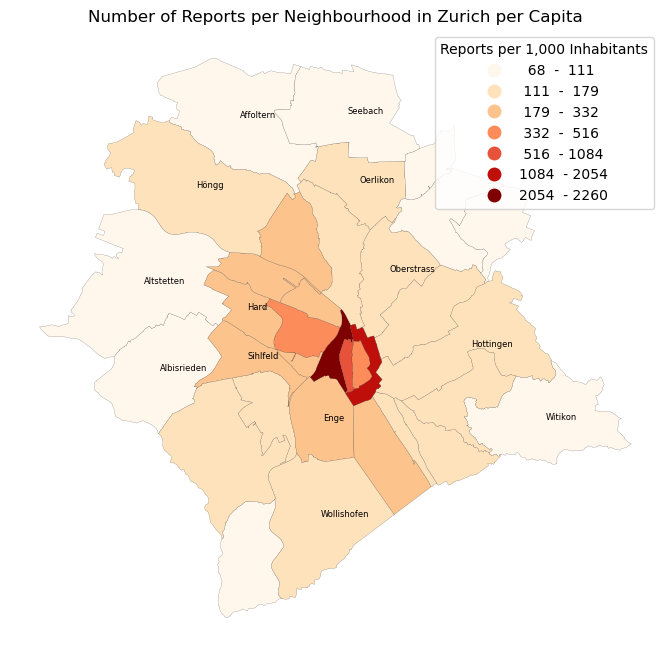

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


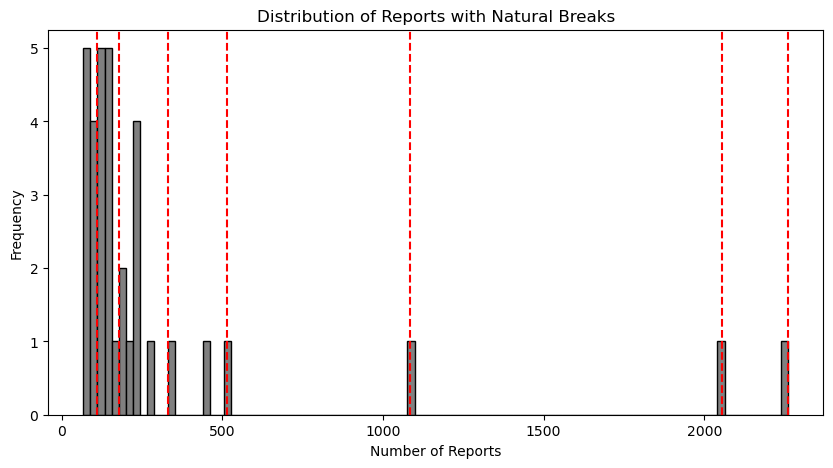

In [120]:
#------------------------------------------------------------------------------------------------
# Data Analysis: 
#------------------------------------------------------------------------------------------------

count = zwn_with_quartiere.groupby(["Quartier"]).size().reset_index(name="count")

reports_popsize = processed_quartiere.merge(count, on="Quartier",how="left")
reports_popsize = reports_popsize.merge(pop_size, on="Quartier",how="left")

reports_popsize["reports_per_capita"] = (reports_popsize["count"]/reports_popsize["PopSize"] *1000)

#----------------------------------------------------------------------------------------------
# Create Chlorpleth Map
#----------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 

reports_popsize.plot(
    column="reports_per_capita",
    scheme = "naturalbreaks",
    k = 7,
    edgecolor = "black",
    legend=True,
    linewidth = 0.1,
    cmap="OrRd",
    ax=ax, #draw the axes on the axes we creaed
    legend_kwds={"title": "Reports per 1,000 Inhabitants","fmt": "{:.0f}"}
)
legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(text.get_text().replace(",", "  -"))
    
ax.set_title("Number of Reports per Neighbourhood in Zurich per Capita")
ax.axis("off")

# add neighbourhood labels
selected_quartiere =reports_popsize[reports_popsize["Quartier"].isin(["Affoltern","Seebach","Oerlikon","Höngg","Altstetten","Albisrieden","Enge","Wollishofen","Witikon","Hottingen","Sihlfeld","Hard","Oberstrass"])]

for i in range(len(selected_quartiere)):

    x = selected_quartiere.iloc[i]["Geometry"].centroid.x
    y = selected_quartiere.iloc[i]["Geometry"].centroid.y
    name = selected_quartiere.iloc[i]["Quartier"]

    ax.text(x, y, name, fontsize=6)


plt.show()
#


#-------------------------------------------------------------------------------------------------
# Create histogram
#-------------------------------------------------------------------------------------------------

import mapclassify

classifier = mapclassify.NaturalBreaks(reports_popsize["reports_per_capita"],k=7)
breaks = classifier.bins

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(reports_popsize["reports_per_capita"], bins=100, color= "grey",edgecolor="black")

for i in breaks:
    plt.axvline(i, color="red", linestyle="--")

plt.title("Distribution of Reports with Natural Breaks")
plt.xlabel("Number of Reports")
plt.ylabel("Frequency")
plt.show()


# Question 3: How do report volumes change overtime in Zurich per category ?

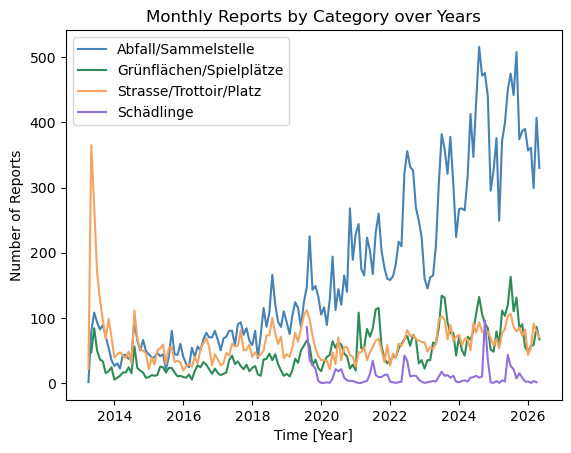

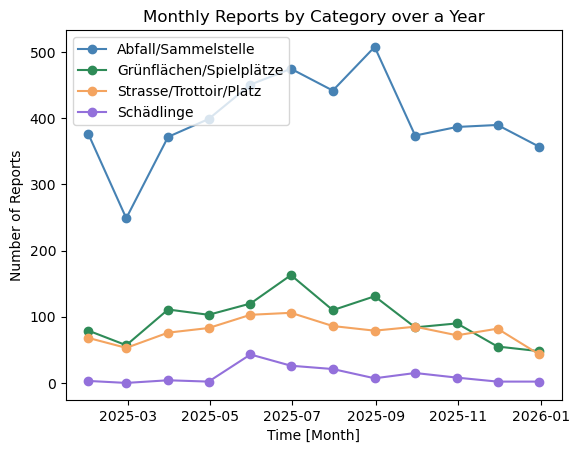

In [121]:
functions.plot_category_over_years(zwn_with_quartiere,["Abfall/Sammelstelle","Grünflächen/Spielplätze","Strasse/Trottoir/Platz","Schädlinge"],time_column="report_time", category_column="category")


functions.plot_category_over_a_year(zwn_with_quartiere,["Abfall/Sammelstelle","Grünflächen/Spielplätze","Strasse/Trottoir/Platz","Schädlinge"],time_column="report_time",category_column="category",year=2025)



## Question 4: How does the proessing time vary across neighbourhoods by category in Zurich ?

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


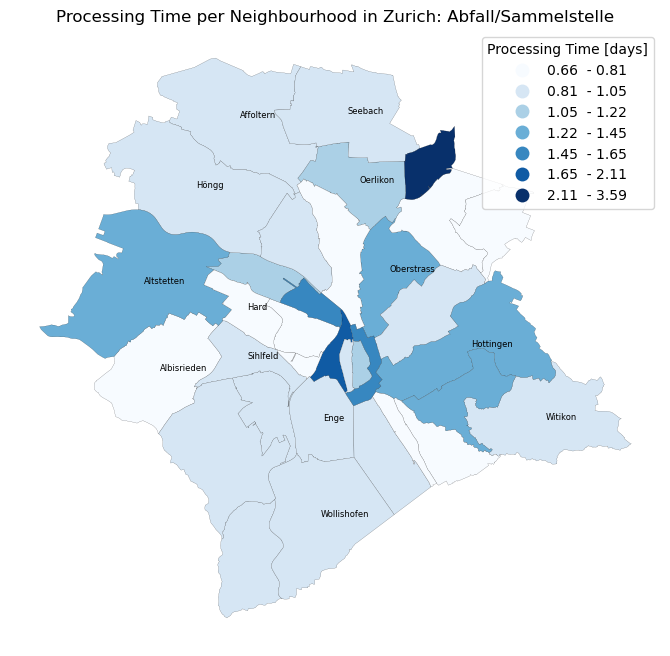

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


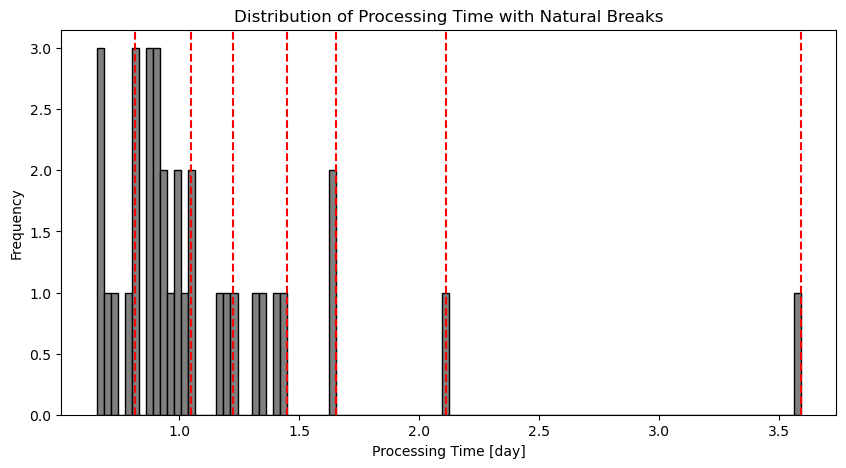

In [123]:
import importlib
importlib.reload(functions)
#-----------------------------------------------------------------------------
# Data Analysis: filter completed reports and calculate mean processing time
#----------------------------------------------------------------------------
zwn_filtred= zwn_with_quartiere[zwn_with_quartiere["status"] =="fixed - council"]
mean = functions.calculate_mean_processing_time(zwn_filtred,"Abfall/Sammelstelle")
map_df = processed_quartiere.merge(mean, on="Quartier",how="left")

#--------------------------------------------------------------------------------
# Create Map
#--------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 

map_df.plot(column="processing_time_float",
            scheme = "naturalbreaks",
            k = 7,
            edgecolor = "black",
            legend=True,
            linewidth = 0.1,
            cmap="Blues",
            ax=ax, #draw the axes on the axes we creaed
            legend_kwds={
                "title": "Processing Time [days]",})
legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(text.get_text().replace(",", "  -"))
ax.set_title("Processing Time per Neighbourhood in Zurich: Abfall/Sammelstelle")
ax.axis("off")

# add neighbourhood labels
selected_quartiere =map_df[map_df["Quartier"].isin(["Affoltern","Seebach","Oerlikon","Höngg","Altstetten","Albisrieden","Enge","Wollishofen","Witikon","Hottingen","Sihlfeld","Hard","Oberstrass"])]

for i in range(len(selected_quartiere)):

    x = selected_quartiere.iloc[i]["Geometry"].centroid.x
    y = selected_quartiere.iloc[i]["Geometry"].centroid.y
    name = selected_quartiere.iloc[i]["Quartier"]

    ax.text(x, y, name, fontsize=6)

plt.show()

#--------------------------------------------------------------------------------------------------------------------------------------------------------------
# Create histogram
#----------------------------------------------------------------------------------------------------------------------------------------------------------
import mapclassify

classifier = mapclassify.NaturalBreaks(map_df["processing_time_float"],k=7)
breaks = classifier.bins

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(map_df["processing_time_float"], bins=100, color= "grey",edgecolor="black")

for i in breaks:
    plt.axvline(i, color="red", linestyle="--")

plt.title("Distribution of Processing Time with Natural Breaks")
plt.xlabel("Processing Time [day]")
plt.ylabel("Frequency")
plt.show()




In [98]:
#-----------------------------------------------------------------------------
# Data Analysis: filter completed reports and calculate mean processing time
#----------------------------------------------------------------------------



        
zwn_filtred= zwn_with_quartiere[zwn_with_quartiere["status"] =="fixed - council"]

results = []

def calculate_mean_processing_time(data,categories):
    for category in categories:
        filter_category= data[data["category"]==category]
        filter_category["processing_time"] =  filter_category["resolved_time"]- filter_category["report_time"]
        counts = filter_category.groupby("Quartier").size().reset_index(name="n")
        valid_quartiere = counts[counts["n"] >= 10]
        filter_category = filter_category.merge(valid_quartiere, on="Quartier",how="inner")
        mean = (filter_category.groupby(["Quartier"])["processing_time"].mean().reset_index())
        mean["processing_time_float"]= mean["processing_time"].dt.total_seconds()/86400
        result.append(mean)
        
    return 

mean = calculate_mean_processing_time(zwn_filtred,["Abfall/Sammelstelle"])
map_df = processed_quartiere.merge(mean, on="Quartier",how="left")


#--------------------------------------------------------------------------------
# Create Map
#--------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 

map_df.plot(column="processing_time_float",
            scheme = "naturalbreaks",
            k = 7,
            edgecolor = "black",
            legend=True,
            linewidth = 0.1,
            cmap="Blues",
            ax=ax, #draw the axes on the axes we creaed
            legend_kwds={
                "title": "Processing Time [days]",})
legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(text.get_text().replace(",", "  -"))
ax.set_title("Processing Time per Neighbourhood in Zurich: Abfall/Sammelstelle")
ax.axis("off")

# add neighbourhood labels
selected_quartiere =map_df[map_df["Quartier"].isin(["Affoltern","Seebach","Oerlikon","Höngg","Altstetten","Albisrieden","Enge","Wollishofen","Witikon","Hottingen","Sihlfeld","Hard","Oberstrass"])]

for i in range(len(selected_quartiere)):

    x = selected_quartiere.iloc[i]["Geometry"].centroid.x
    y = selected_quartiere.iloc[i]["Geometry"].centroid.y
    name = selected_quartiere.iloc[i]["Quartier"]

    ax.text(x, y, name, fontsize=6)

plt.show()

#--------------------------------------------------------------------------------------------------------------------------------------------------------------
# Create histogram
#----------------------------------------------------------------------------------------------------------------------------------------------------------
import mapclassify

classifier = mapclassify.NaturalBreaks(map_df["processing_time_float"],k=7)
breaks = classifier.bins

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(map_df["processing_time_float"], bins=100, color= "grey",edgecolor="black")

for i in breaks:
    plt.axvline(i, color="red", linestyle="--")

plt.title("Distribution of Processing Time with Natural Breaks")
plt.xlabel("Processing Time [day]")
plt.ylabel("Frequency")
plt.show()

test = map_df[map_df["Quartier"]=="Saatlen"]


AttributeError: 'DataFrame' object has no attribute 'append'

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


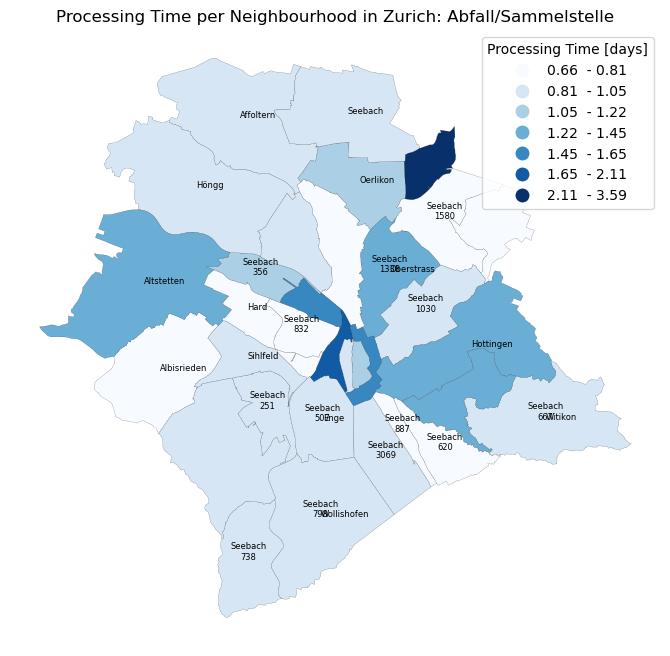

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


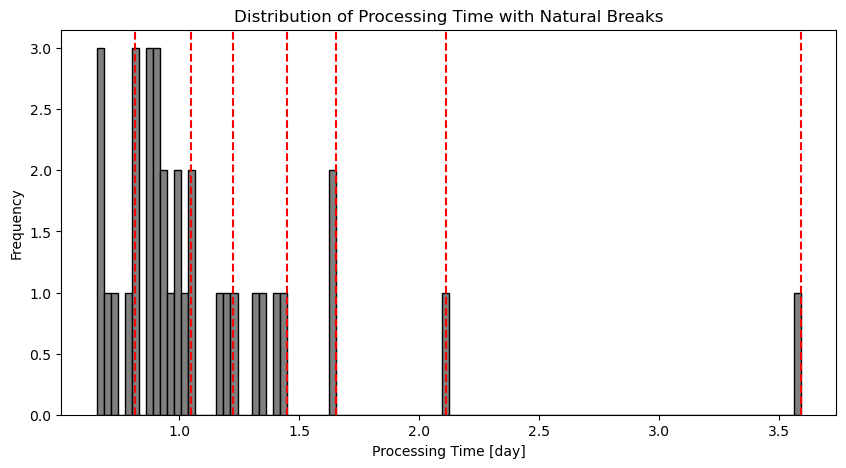

In [97]:
#-----------------------------------------------------------------------------
# Data Analysis: filter completed reports and calculate mean processing time
#----------------------------------------------------------------------------


#
zwn_filtred= zwn_with_quartiere[zwn_with_quartiere["status"] =="fixed - council"]

filter_category= zwn_filtred[zwn_filtred["category"]=="Abfall/Sammelstelle"]

filter_category["processing_time"] =  (filter_category["resolved_time"]- filter_category["report_time"])

mean = filter_category.groupby(["Quartier"])["processing_time"].mean().reset_index()
mean["processing_time_float"]= mean["processing_time"].dt.total_seconds()/86400

count = filter_category.groupby(["Quartier"])["processing_time"].size().reset_index(name="count")
map_df = processed_quartiere.merge(mean, on="Quartier",how="left")
map_df = map_df.merge(count, on="Quartier", how="left")



#--------------------------------------------------------------------------------
# Create Map
#--------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 

map_df.plot(column="processing_time_float",
            scheme = "naturalbreaks",
            k = 7,
            edgecolor = "black",
            legend=True,
            linewidth = 0.1,
            cmap="Blues",
            ax=ax, #draw the axes on the axes we creaed
            legend_kwds={
                "title": "Processing Time [days]",})
legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(text.get_text().replace(",", "  -"))
ax.set_title("Processing Time per Neighbourhood in Zurich: Abfall/Sammelstelle")
ax.axis("off")

# add neighbourhood labels
selected_quartiere =map_df[map_df["Quartier"].isin(["Affoltern","Seebach","Oerlikon","Höngg","Altstetten","Albisrieden","Enge","Wollishofen","Witikon","Hottingen","Sihlfeld","Hard","Oberstrass"])]

for i in range(len(selected_quartiere)):

    x = selected_quartiere.iloc[i]["Geometry"].centroid.x
    y = selected_quartiere.iloc[i]["Geometry"].centroid.y
    name = selected_quartiere.iloc[i]["Quartier"]
    ax.text(x, y, name, fontsize=6)
    

plt.show()

#--------------------------------------------------------------------------------------------------------------------------------------------------------------
# Create histogram
#----------------------------------------------------------------------------------------------------------------------------------------------------------
import mapclassify

classifier = mapclassify.NaturalBreaks(map_df["processing_time_float"],k=7)
breaks = classifier.bins

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(map_df["processing_time_float"], bins=100, color= "grey",edgecolor="black")

for i in breaks:
    plt.axvline(i, color="red", linestyle="--")

plt.title("Distribution of Processing Time with Natural Breaks")
plt.xlabel("Processing Time [day]")
plt.ylabel("Frequency")
plt.show()




